0.23
0.8253600000000001
0.7934988902399996
0.7549810004098534
0.7248225875483237
0.8657213827838397
0.4581303756011399
0.09661902301378111
0.6083369950472445
0.9418783789167894
0.38110930441397917
0.9198751177785438
0.28827850027937935
0.8604265071446368
0.7620597163094451
0.7278926527471877
0.03185374944366237
0.17150662502811093
0.822610634075051
0.5821008450172521
0.1633866787268068
0.6447167032255324
0.15606272076350391
0.552292115595085
0.20983525616715815
0.7015973847419974
0.09760675404190922
0.36513343326421116
0.08137553634493622
0.45282406761599786
0.1418200257444464
0.6492820736704791
0.03991187691107356
0.4073488389720422
0.962391933143968
0.33658801225468693
0.10582504297616557
0.42474520003797334
0.22924339864611287
0.701679178780313
0.9434877315402116
0.20828638482145717
0.6898332646621118
0.10218471329146017
0.3938296375077355
0.16670552553469942
0.5997141565398723
0.217945451769735
0.6799012405492071
0.9932495264797686
0.3066593486720676
0.8822666878061409
0.6923843582

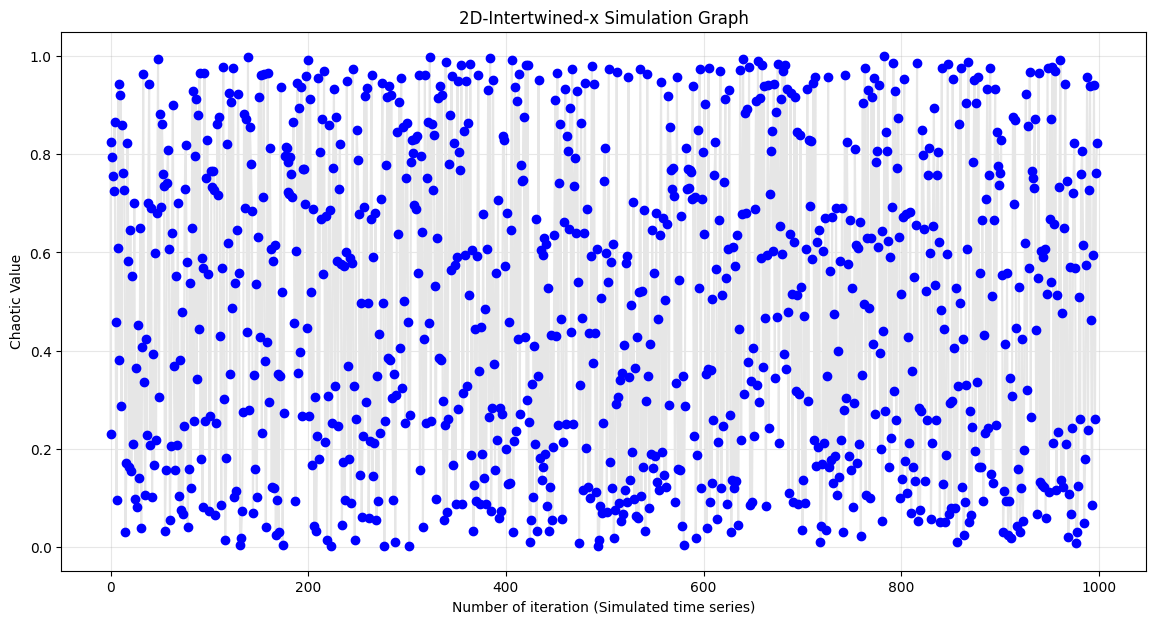

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def intertwined_logistic_map(x0, y0, mu=3.9, beta=0.3, n=1000):
    x = np.zeros(n)
    y = np.zeros(n)

    x[0], y[0] = x0, y0
    iterations =[0]

    for i in range(n-1):
        x[i+1] = (mu * x[i] * (1 - x[i]) + beta * y[i]**2) % 1
        y[i+1] = (mu * y[i] * (1 - y[i]) + beta * x[i]**2) % 1
        iterations.append(i)

    return x, y , iterations

# Initial conditions
x0, y0 = 0.23, 0.67

x, y , iterations = intertwined_logistic_map(x0, y0, n=1000)

for e in list(x):
    print(float(e))

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(
    iterations,
    list(x),
    color='#e6e6e6',        # slightly visible off-white line
    linewidth=1.5,          # helps visibility
    marker='o',
    markerfacecolor='blue',
    markeredgecolor='blue'
)

plt.xlabel("Number of iteration (Simulated time series)")
plt.ylabel("Chaotic Value")
plt.title("2D-Intertwined-x Simulation Graph")

plt.grid(True, alpha=0.3)  # softer grid so it doesn’t overpower
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import math


# 🔹 Entropy
def entropy_test(series):
    keys = [int(x * 256) for x in series]
    count = Counter(keys)
    total = len(keys)
    entropy = -sum((c/total) * math.log2(c/total) for c in count.values())
    return entropy


# 🔹 Autocorrelation (lag 1)
def autocorrelation_value(series):
    z = np.array(series)
    z_mean = np.mean(z)
    num = np.sum((z[:-1] - z_mean) * (z[1:] - z_mean))
    den = np.sum((z - z_mean) ** 2)
    return num / den


# 🔹 Correlation coefficient
def correlation_coeff(series):
    x = np.array(series[:-1])
    y = np.array(series[1:])
    return np.corrcoef(x, y)[0, 1]


# 🔹 MASTER TEST FUNCTION
def test_randomness(series):
    print("========== RANDOMNESS TEST REPORT ==========\n")

    arr = np.array(series)

    # 🔸 Mean
    mean = np.mean(arr)
    print("Mean:")
    print(f"  Value: {mean:.5f}")
    print("  Ideal: 0.5")
    print("  Accepted: 0.48 – 0.52")
    if 0.48 <= mean <= 0.52:
        print("  Result: PASS\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Variance
    variance = np.var(arr)
    print("Variance:")
    print(f"  Value: {variance:.5f}")
    print("  Ideal: 0.0833")
    print("  Accepted: 0.07 – 0.09")
    if 0.07 <= variance <= 0.09:
        print("  Result: PASS\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Entropy
    entropy = entropy_test(series)
    print("Entropy:")
    print(f"  Value: {entropy:.5f}")
    print("  Ideal: 8")
    print("  Accepted: ≥ 7.5 (≥7.9 excellent)")
    if entropy >= 7.9:
        print("  Result: EXCELLENT\n")
    elif entropy >= 7.5:
        print("  Result: PASS (GOOD)\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Autocorrelation
    auto = autocorrelation_value(series)
    print("Autocorrelation (lag 1):")
    print(f"  Value: {auto:.5f}")
    print("  Ideal: 0")
    print("  Accepted: |value| < 0.05")
    if abs(auto) < 0.05:
        print("  Result: PASS\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Correlation
    corr = correlation_coeff(series)
    print("Correlation (x_n vs x_n+1):")
    print(f"  Value: {corr:.5f}")
    print("  Ideal: 0")
    print("  Accepted: -0.05 to 0.05")
    if -0.05 <= corr <= 0.05:
        print("  Result: PASS\n")
    else:
        print("  Result: FAIL\n")

    # 🔸 Histogram
    print("Histogram:")
    print("  Ideal: Uniform (flat distribution)")
    print("  Check visually in the plot")

    plt.figure()
    plt.hist(series, bins=50)
    plt.title("Histogram")
    plt.show()

    # 🔸 Correlation Plot
    plt.figure()
    plt.scatter(series[:-1], series[1:], s=1)
    plt.title("Correlation Plot")
    plt.show()

    print("\n========== TESTING COMPLETE ==========")

========== RANDOMNESS TEST REPORT ==========

Mean:
  Value: 0.50517
  Ideal: 0.5
  Accepted: 0.48 – 0.52
  Result: PASS

Variance:
  Value: 0.10214
  Ideal: 0.0833
  Accepted: 0.07 – 0.09
  Result: FAIL

Entropy:
  Value: 7.71478
  Ideal: 8
  Accepted: ≥ 7.5 (≥7.9 excellent)
  Result: PASS (GOOD)

Autocorrelation (lag 1):
  Value: -0.06775
  Ideal: 0
  Accepted: |value| < 0.05
  Result: FAIL

Correlation (x_n vs x_n+1):
  Value: -0.06782
  Ideal: 0
  Accepted: -0.05 to 0.05
  Result: FAIL

Histogram:
  Ideal: Uniform (flat distribution)
  Check visually in the plot


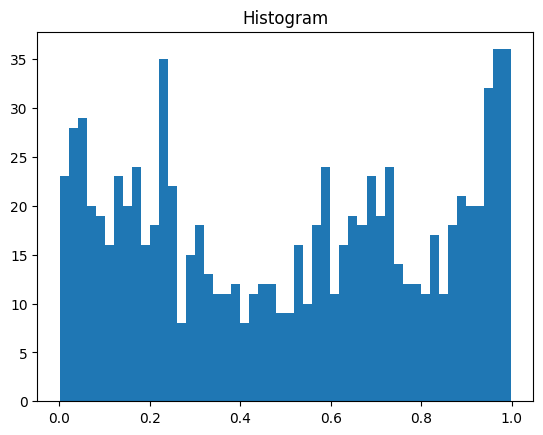

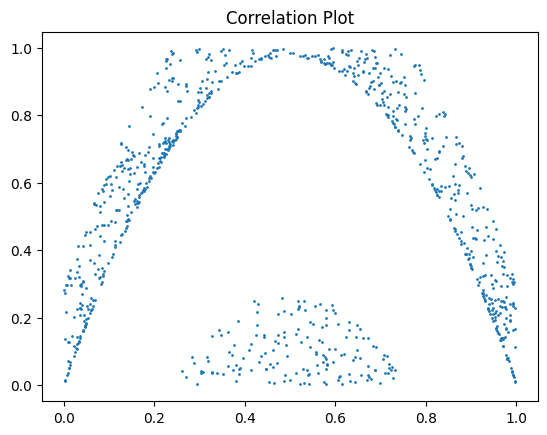


========== TESTING COMPLETE ==========


In [12]:
test_randomness(list(y)[100:])